In [49]:
# imports libraries

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import bigquery


from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1773760060.610890   61258 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773760061.201178   61258 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773760064.104596   61258 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [50]:
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Project root: /home/dd4real2k/code/mlbh/GridZero


In [51]:
from python_scripts.data_to_bigquery import load_from_bigquery
from python_scripts.hgb_pipeline import hgb_train_preproc

In [52]:
# Load Dataset from BigQuery

client = bigquery.Client(project="gridzero-489711")

query = """
SELECT *
FROM `gridzero-489711.merged_set.full_feature_engineered_data_test`
ORDER BY datetime
"""

df = client.query(query).to_dataframe()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (148991, 31)


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,carbon_intensity_gco2_kwh,hour_sin,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520
0,2017-09-12 00:00:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,142.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
1,2017-09-12 00:30:00+00:00,11.6,31.0,28.1,4.0,0.0,0.0,0.0,1001.2,0.0,...,140.0,0.000000,1.000000,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
2,2017-09-12 01:00:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,139.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
3,2017-09-12 01:30:00+00:00,11.2,30.3,27.0,5.0,0.0,0.0,0.0,1001.9,0.0,...,137.0,0.258819,0.965926,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN
4,2017-09-12 02:00:00+00:00,10.9,29.6,25.2,7.0,0.0,0.0,0.0,1002.4,0.0,...,132.0,0.500000,0.866025,0.781831,0.62349,-0.948362,-0.317191,NaN,NaN,NaN


In [53]:
target_col = "carbon_intensity_gco2_kwh"
datetime_col = "datetime"

df = hgb_train_preproc(
    df,
    target_col=target_col,
    datetime_col=datetime_col
)

print("Processed shape:", df.shape)
df.head()

Processed shape: (130766, 33)


,datetime,temperature_2m_c,wind_speed_100m_ms,wind_gusts_10m_ms,cloud_cover_pct,shortwave_radiation_wm2,direct_radiation_wm2,diffuse_radiation_wm2,pressure_msl_hpa,precipitation_mm,...,hour_cos,dow_sin,dow_cos,doy_sin,doy_cos,carbon_lag_48,carbon_lag_336,carbon_lag_17520,carbon_roll_24h,carbon_roll_168h
0,2018-09-15 12:00:00+00:00,19.2,17.2,27.7,98.0,490.0,303.0,187.0,1024.2,0.0,...,-1.000000,-0.974928,-0.222521,-0.963471,-0.267814,211.0,255.0,270.0,239.625000,228.375000
1,2018-09-15 12:30:00+00:00,19.2,17.2,27.7,98.0,490.0,303.0,187.0,1024.2,0.0,...,-1.000000,-0.974928,-0.222521,-0.963471,-0.267814,212.0,255.0,249.0,243.875000,229.077381
2,2018-09-15 13:00:00+00:00,19.5,17.9,26.6,99.0,364.0,118.0,246.0,1023.8,0.0,...,-0.965926,-0.974928,-0.222521,-0.963471,-0.267814,214.0,248.0,262.0,247.708333,229.785714
3,2018-09-15 13:30:00+00:00,19.5,17.9,26.6,99.0,364.0,118.0,246.0,1023.8,0.0,...,-0.965926,-0.974928,-0.222521,-0.963471,-0.267814,215.0,239.0,251.0,251.250000,230.446429
4,2018-09-15 14:00:00+00:00,19.5,15.7,26.3,99.0,257.0,46.0,211.0,1023.4,0.0,...,-0.866025,-0.974928,-0.222521,-0.963471,-0.267814,203.0,235.0,257.0,254.208333,231.065476


In [55]:
X = df.drop(columns=[target_col, datetime_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (130766, 31)
y shape: (130766,)


In [58]:
feature_cols = X.columns.tolist()


In [60]:
# LSTM Sequences
def create_sequences(dataframe, feature_cols, target_col, lookback=24):
    X_seq, y_seq = [], []

    values = dataframe[feature_cols + [target_col]].values

    for i in range(lookback, len(values)):
        X_seq.append(values[i - lookback:i, :-1])
        y_seq.append(values[i, -1])

    return np.array(X_seq), np.array(y_seq)

In [61]:
# Sequence dataset

lookback = 24

X_lstm, y_lstm = create_sequences(
    dataframe=df,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=lookback
)

print("X_lstm shape:", X_lstm.shape)
print("y_lstm shape:", y_lstm.shape)

X_lstm shape: (130742, 24, 31)
y_lstm shape: (130742,)


In [62]:
# Time split for LSTM

split_lstm = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split_lstm]
X_test_lstm = X_lstm[split_lstm:]
y_train_lstm = y_lstm[:split_lstm]
y_test_lstm = y_lstm[split_lstm:]

print("Train LSTM:", X_train_lstm.shape, y_train_lstm.shape)
print("Test LSTM:", X_test_lstm.shape, y_test_lstm.shape)

Train LSTM: (104593, 24, 31) (104593,)
Test LSTM: (26149, 24, 31) (26149,)


In [38]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (104612, 31) (104612,)
Test shape: (26154, 31) (26154,)


In [63]:
# LSTM model

lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

/home/dd4real2k/.pyenv/versions/3.12.9/envs/gridzero/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,537 (146.63 KB)

 Trainable params: 37,537 (146.63 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# train LSTM

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
2942/2942 ━━━━━━━━━━━━━━━━━━━━ 62s 20ms/step - loss: 6572.2881 - val_loss: 1944.0793
Epoch 2/30
2942/2942 ━━━━━━━━━━━━━━━━━━━━ 57s 19ms/step - loss: 1541.8259 - val_loss: 1137.6454
Epoch 3/30
2942/2942 ━━━━━━━━━━━━━━━━━━━━ 60s 20ms/step - loss: 1301.4655 - val_loss: 1777.6223
Epoch 4/30
2942/2942 ━━━━━━━━━━━━━━━━━━━━ 52s 18ms/step - loss: 1247.3813 - val_loss: 1845.9443
Epoch 5/30
2942/2942 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - loss: 1198.7585 - val_loss: 1346.7594
Epoch 6/30
2942/2942 ━━━━━━━━━━━━━━━━━━━━ 51s 17ms/step - loss: 1156.9703 - val_loss: 1682.5791
Epoch 7/30
2942/2942 ━━━━━━━━━━━━━━━━━━━━ 59s 20ms/step - loss: 1101.5831 - val_loss: 1368.5487


In [66]:
lstm_preds = lstm_model.predict(X_test_lstm).flatten()
lstm_preds[:10]

818/818 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


array([ 78.52783 ,  90.06289 ,  96.95744 , 105.488335, 111.12362 ,
       129.8707  , 141.70685 , 146.52005 , 147.55856 , 147.3184  ],
      dtype=float32)

In [68]:
# Evaluate LSTM metrics

lstm_mae = mean_absolute_error(y_test_lstm, lstm_preds)
lstm_rmse = mean_squared_error(y_test_lstm, lstm_preds) ** 0.5
lstm_r2 = r2_score(y_test_lstm, lstm_preds)

print("LSTM MAE :", round(lstm_mae, 4))
print("LSTM RMSE:", round(lstm_rmse, 4))
print("LSTM R2  :", round(lstm_r2, 4))

LSTM MAE : 20.4785
LSTM RMSE: 26.397
LSTM R2  : 0.7983


# All Models

In [79]:
models = {
    "HGB": HistGradientBoostingRegressor(
        max_iter=300,
        learning_rate=0.05,
        max_depth=10,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=10,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}


# Train and evaluate all models

In [80]:
results = []
predictions = {}

# tabular models
for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    predictions[name] = preds

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# add LSTM after tabular models
results.append({
    "Model": "LSTM",
    "MAE": lstm_mae,
    "RMSE": lstm_rmse,
    "R2": lstm_r2
})

predictions["LSTM"] = lstm_preds


Training HGB...

Training Random Forest...

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.015063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6579
[LightGBM] [Info] Number of data points in the train set: 104612, number of used features: 31
[LightGBM] [Info] Start training from score 178.787215

Training XGBoost...


In [81]:
# Comparisom table

comparison_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
comparison_df

,Model,MAE,RMSE,R2
0,XGBoost,9.053274,11.748640,0.960058
1,LightGBM,9.399578,12.222107,0.956774
2,HGB,9.913468,12.911356,0.951761
3,Random Forest,12.150948,15.612243,0.929469
4,LSTM,20.478472,26.396967,0.798349


In [83]:
# Best model

best_model = comparison_df.iloc[0]
print("Best model by RMSE:")
print(best_model)

Best model by RMSE:
Model     XGBoost
MAE      9.053274
RMSE     11.74864
R2       0.960058
Name: 0, dtype: object


In [84]:
print(f"Best model: {comparison_df.iloc[0]['Model']}")

Best model: XGBoost


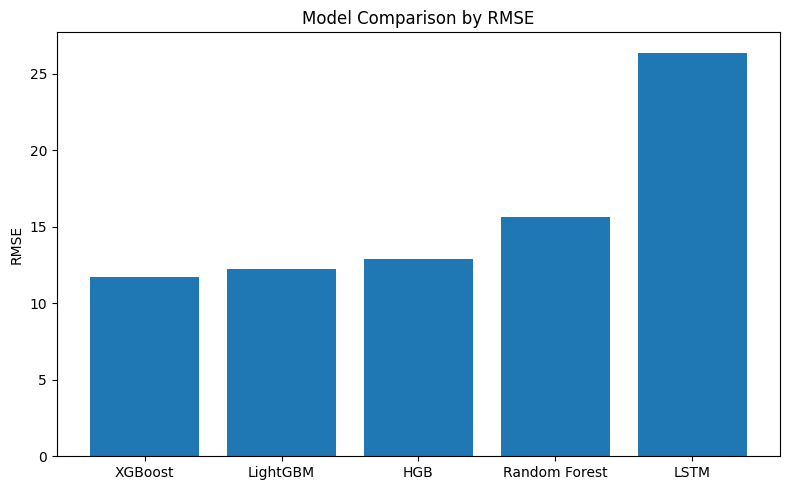

In [85]:
# RMSE comparison

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

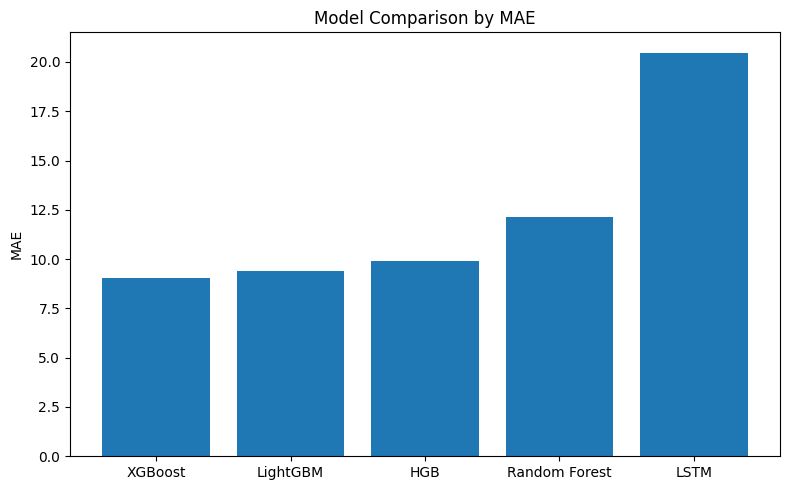

In [86]:
# MAE Comparison

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["MAE"])
plt.title("Model Comparison by MAE")
plt.ylabel("MAE")
plt.tight_layout()
plt.show()

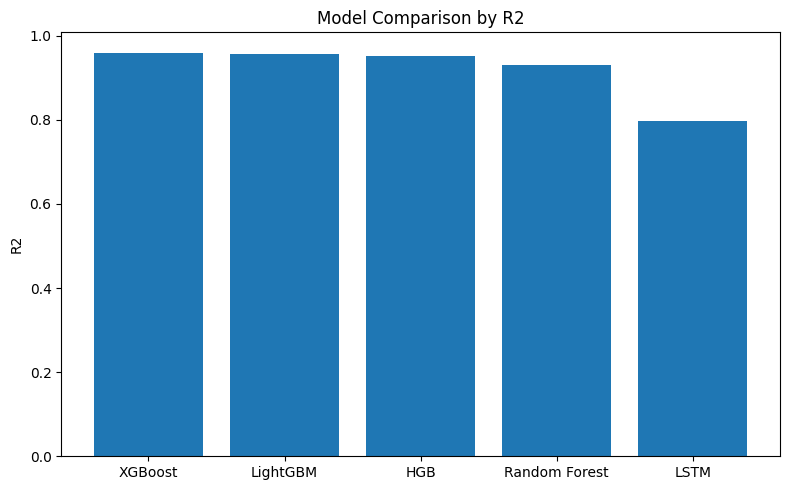

In [87]:
# Plot R2 comparison
plt.figure(figsize=(8, 5))
plt.bar(comparison_df["Model"], comparison_df["R2"])
plt.title("Model Comparison by R2")
plt.ylabel("R2")
plt.tight_layout()
plt.show()

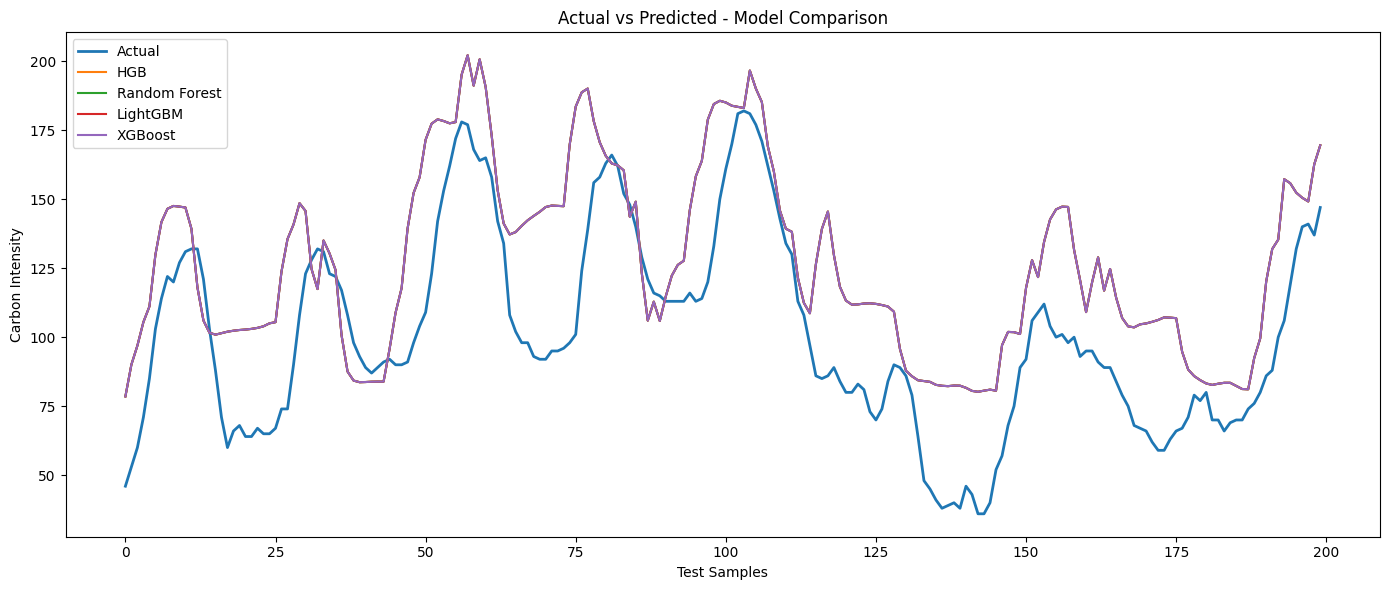

In [90]:
# actual vs predicted

plt.figure(figsize=(14, 6))
plt.plot(y_test.values[:200], label="Actual", linewidth=2)

for model_name in ["HGB", "Random Forest", "LightGBM", "XGBoost"]:
    plt.plot(preds[:200], label=model_name)

plt.title("Actual vs Predicted - Model Comparison")
plt.xlabel("Test Samples")
plt.ylabel("Carbon Intensity")
plt.legend()
plt.tight_layout()
plt.show()

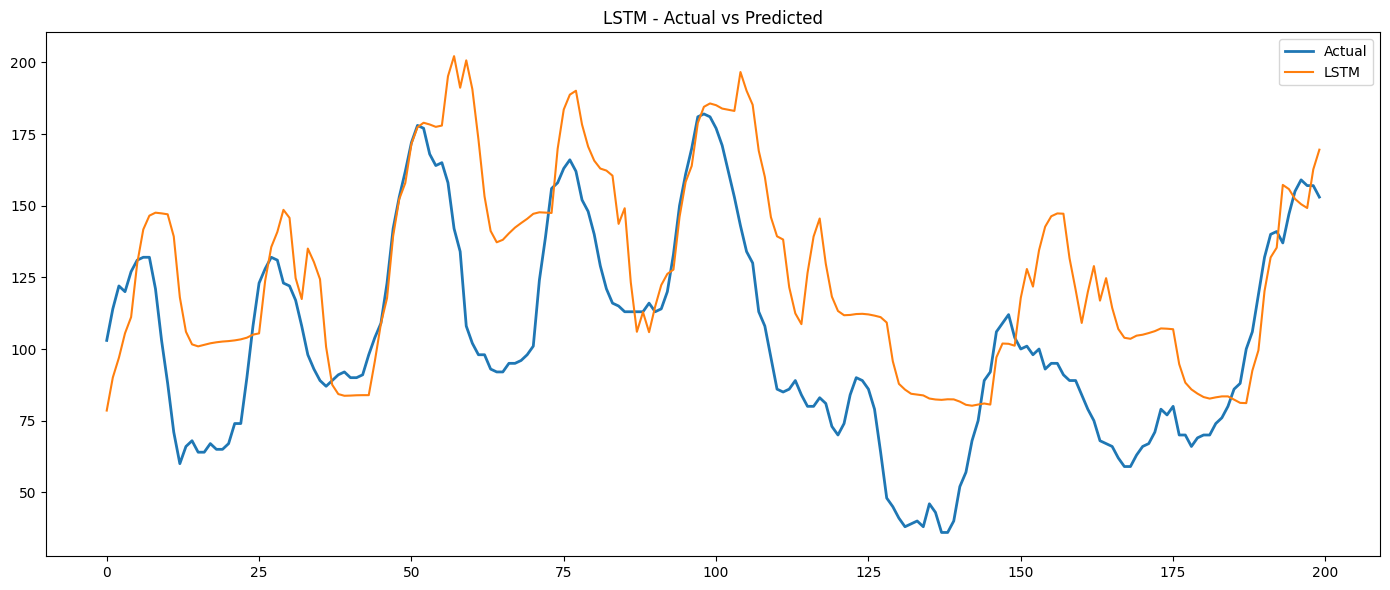

In [92]:
# LSTM Plot
plt.figure(figsize=(14, 6))
plt.plot(y_test_lstm[:200], label="Actual", linewidth=2)
plt.plot(predictions["LSTM"][:200], label="LSTM")

plt.title("LSTM - Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# os.makedirs("../models", exist_ok=True)

# comparison_df.to_csv("../models/model_comparison_results.csv", index=False)
# print("Comparison results saved.")